In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Mango Leafe Disease Classification

Dataset credits: https://www.kaggle.com/datasets/aryashah2k/mango-leaf-disease-dataset

### Import all the Dependencies

In [ ]:
!pip install --upgrade tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 21.4 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.34.1 which is incompatible

In [3]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from IPython.display import HTML
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [4]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


### Set all the Constants

In [9]:
BATCH_SIZE = 64
IMAGE_WIDTH = 256 # Standardizing to a square size
IMAGE_HEIGHT = 256 # Standardizing to a square size
CHANNELS=3
EPOCHS=35

### Import data into tensorflow dataset object

We will use image_dataset_from_directory api to load all images in tensorflow dataset: https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image_dataset_from_directory

In [ ]:
# dataset = tf.keras.preprocessing.image_dataset_from_directory(
#     "/content/drive/MyDrive/Mango_Leafe_Care_App/MangoLeafBD_Disease_Dataset_Splitted",
#     seed=123,
#     shuffle=True,
#     image_size=(IMAGE_HEIGHT,IMAGE_WIDTH),
#     batch_size=BATCH_SIZE
# )

### Loading pre-split datasets

In [5]:
import sys
!{sys.executable} -m pip install patool

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 3.6 MB/s eta 0:00:00


In [6]:
import patoolib
import os

rar_file_path = "/content/drive/MyDrive/Mango_Leafe_Care_App/MangoLeafBD_Disease_Dataset_Splitted_train~val~test=70~20~10.rar"
extraction_path = "/content/MangoLeafBD_Dataset_Unzipped_train~val~test=70~20~10"

# Create the directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

print(f"Extracting {rar_file_path} to {extraction_path}...")
patoolib.extract_archive(rar_file_path, outdir=extraction_path)
print("Extraction complete!")

# Verify extraction
print(f"Contents of {extraction_path}:")
print(os.listdir(extraction_path))

Extracting /content/drive/MyDrive/Mango_Leafe_Care_App/MangoLeafBD_Disease_Dataset_Splitted_train~val~test=70~20~10.rar to /content/MangoLeafBD_Dataset_Unzipped_train~val~test=70~20~10...


INFO patool: Extracting /content/drive/MyDrive/Mango_Leafe_Care_App/MangoLeafBD_Disease_Dataset_Splitted_train~val~test=70~20~10.rar ...
INFO patool: running /usr/bin/unrar x -kb -or -- /content/drive/MyDrive/Mango_Leafe_Care_App/MangoLeafBD_Disease_Dataset_Splitted_train~val~test=70~20~10.rar
INFO patool: ... /content/drive/MyDrive/Mango_Leafe_Care_App/MangoLeafBD_Disease_Dataset_Splitted_train~val~test=70~20~10.rar extracted to `/content/MangoLeafBD_Dataset_Unzipped_train~val~test=70~20~10'.


Extraction complete!
Contents of /content/MangoLeafBD_Dataset_Unzipped_train~val~test=70~20~10:
['MangoLeafBD_Disease_Dataset_Splitted_train~val~test=70~20~10']


In [7]:
# Update data loading to use the unzipped dataset
unzipped_dataset_base_path = "/content/MangoLeafBD_Dataset_Unzipped_train~val~test=70~20~10/MangoLeafBD_Disease_Dataset_Splitted_train~val~test=70~20~10"

In [10]:
# 1. LOAD DATASETS (They are already resized here!)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(unzipped_dataset_base_path, "train"),
    seed=123, shuffle=True, image_size=(IMAGE_HEIGHT,IMAGE_WIDTH), batch_size=BATCH_SIZE)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(unzipped_dataset_base_path, "val"),
    seed=123, shuffle=True, image_size=(IMAGE_HEIGHT,IMAGE_WIDTH), batch_size=BATCH_SIZE)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(unzipped_dataset_base_path, "test"),
    seed=123, shuffle=True, image_size=(IMAGE_HEIGHT,IMAGE_WIDTH), batch_size=BATCH_SIZE)


Found 2800 files belonging to 8 classes.
Found 800 files belonging to 8 classes.
Found 400 files belonging to 8 classes.


In [11]:
class_names = train_ds.class_names # Using train_ds as source for class names
class_names

['Anthracnose',
 'Bacterial Canker',
 'Cutting Weevil',
 'Die Back',
 'Gall Midge',
 'Healthy',
 'Powdery Mildew',
 'Sooty Mould']

### Normalize the datasets directly

In [12]:
# 2. THE CRITICAL FIX: Normalize the datasets directly using .map()
# This ensures the model only ever sees 0.0 to 1.0, and the math is NOT saved in the model file.
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=tf.data.AUTOTUNE)

### Cache, Shuffle, and Prefetch the Dataset

In [13]:
# 3. Cache and Prefetch for speed
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

## Building the Model

### Model Architecture

In [ ]:
# 4. BUILD THE ARCHITECTURE (Pure Feature Extractor)
n_classes = len(class_names)
inputs = tf.keras.Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, CHANNELS))

# Notice there is NO resize_and_rescale variable here anymore!
# The model takes the 0.0-1.0 data straight into the Conv2D layer.

# Block 1
x = layers.Conv2D(32, kernel_size=(3,3), activation='relu')(inputs)
x = layers.MaxPooling2D((2, 2))(x)

# Block 2
x = layers.Conv2D(64, kernel_size=(3,3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

# Block 3
x = layers.Conv2D(64, kernel_size=(3,3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.2)(x)

# Block 4
x = layers.Conv2D(128, kernel_size=(3,3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.3)(x)

# Classifier
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(n_classes, activation='softmax')(x)

In [ ]:
model = tf.keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,342,600 (12.75 MB)

 Trainable params: 3,342,600 (12.75 MB)

 Non-trainable params: 0 (0.00 B)

### Compiling the Model
We use `adam` Optimizer, `SparseCategoricalCrossentropy` for losses, `accuracy` as a metric

In [ ]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [ ]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', # Monitor validation loss
    factor=0.2,         # Reduce learning rate by a factor of 0.2 (i.e., new_lr = old_lr * 0.2)
    patience=5,         # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=0.00001,     # Lower bound on the learning rate
    verbose=1
)

history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=2,
    epochs=EPOCHS,
    callbacks=[reduce_lr] # Add the callback here
)

Epoch 1/35
44/44 - 133s - 3s/step - accuracy: 0.2468 - loss: 1.8889 - val_accuracy: 0.4475 - val_loss: 1.5672 - learning_rate: 0.0010
Epoch 2/35
44/44 - 131s - 3s/step - accuracy: 0.4657 - loss: 1.4229 - val_accuracy: 0.6800 - val_loss: 1.0613 - learning_rate: 0.0010
Epoch 3/35
44/44 - 131s - 3s/step - accuracy: 0.6261 - loss: 1.0019 - val_accuracy: 0.6550 - val_loss: 0.9177 - learning_rate: 0.0010
Epoch 4/35
44/44 - 131s - 3s/step - accuracy: 0.6761 - loss: 0.8444 - val_accuracy: 0.7575 - val_loss: 0.6838 - learning_rate: 0.0010
Epoch 5/35
44/44 - 131s - 3s/step - accuracy: 0.7032 - loss: 0.8043 - val_accuracy: 0.8200 - val_loss: 0.5086 - learning_rate: 0.0010
Epoch 6/35
44/44 - 131s - 3s/step - accuracy: 0.7704 - loss: 0.6369 - val_accuracy: 0.8625 - val_loss: 0.4039 - learning_rate: 0.0010
Epoch 7/35
44/44 - 131s - 3s/step - accuracy: 0.7850 - loss: 0.5739 - val_accuracy: 0.8587 - val_loss: 0.4386 - learning_rate: 0.0010
Epoch 8/35
44/44 - 131s - 3s/step - accuracy: 0.8200 - loss: 0

In [ ]:
scores = model.evaluate(test_ds)

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 604ms/step - accuracy: 0.9725 - loss: 0.0997


In [ ]:
scores

[0.09974601119756699, 0.9725000262260437]

Scores is just a list containing loss and accuracy value

### Plotting the Accuracy and Loss Curves

In [ ]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])

**loss, accuracy, val loss etc are a python list containing values of loss, accuracy etc at the end of each epoch**

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

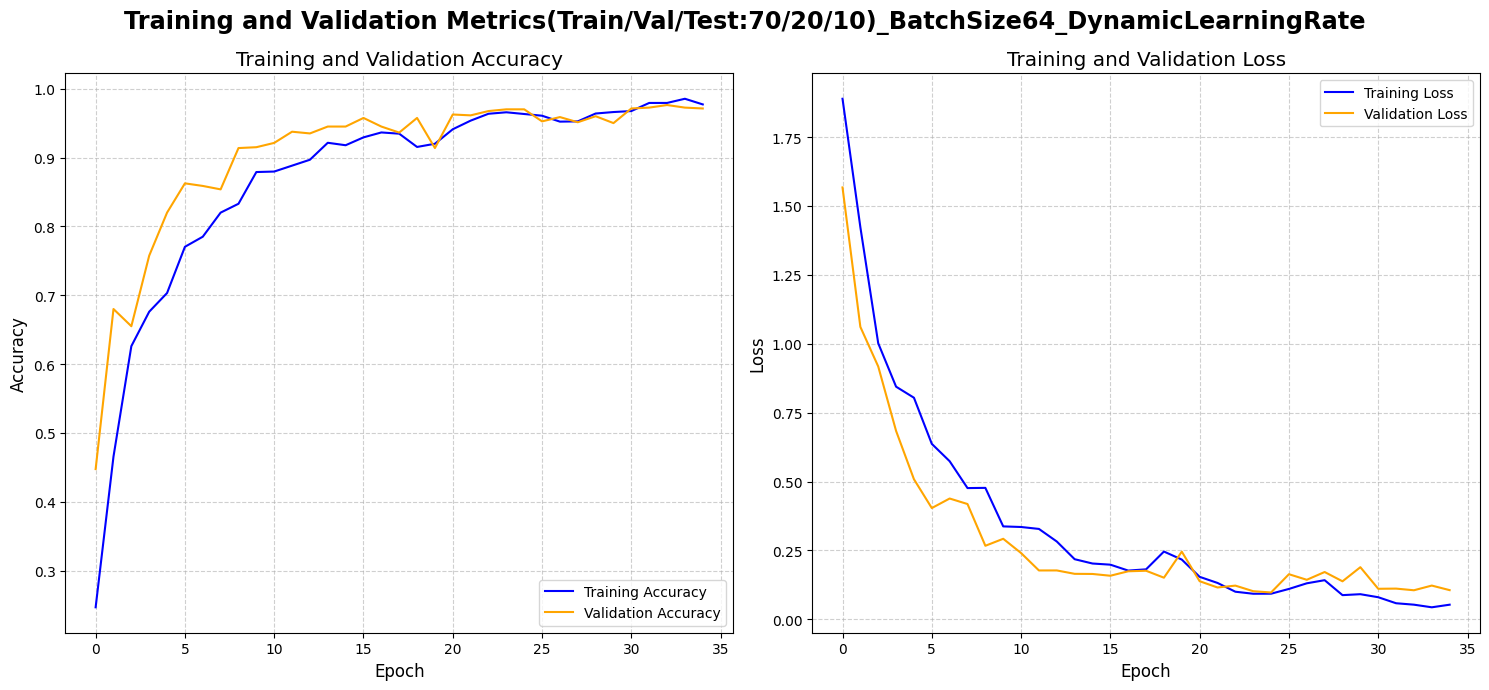

In [ ]:
plt.figure(figsize=(15, 7))
plt.suptitle('Training and Validation Metrics(Train/Val/Test:70/20/10)_BatchSize64_DynamicLearningRate', fontsize='xx-large', weight='bold') # Added a main title to the figure

plt.subplot(1, 2, 1)
plt.plot(range(len(acc)), acc, label='Training Accuracy', color='blue')
plt.plot(range(len(val_acc)), val_acc, label='Validation Accuracy', color='orange')
plt.legend(loc='lower right', fontsize='medium') # Adjusted legend font size and position
plt.title('Training and Validation Accuracy', fontsize='x-large') # Larger title
plt.xlabel('Epoch', fontsize='large') # Added x-axis label
plt.ylabel('Accuracy', fontsize='large') # Added y-axis label
plt.grid(True, linestyle='--', alpha=0.6) # Added grid for better readability

plt.subplot(1, 2, 2)
plt.plot(range(len(loss)), loss, label='Training Loss', color='blue')
plt.plot(range(len(val_loss)), val_loss, label='Validation Loss', color='orange')
plt.legend(loc='upper right', fontsize='medium') # Adjusted legend font size and position
plt.title('Training and Validation Loss', fontsize='x-large') # Larger title
plt.xlabel('Epoch', fontsize='large') # Added x-axis label
plt.ylabel('Loss', fontsize='large') # Added y-axis label
plt.grid(True, linestyle='--', alpha=0.6) # Added grid for better readability

plt.tight_layout() # Adjusts plot parameters for a tight layout
plt.show()

### Run prediction on a sample image

first image to predict
actual label: Bacterial Canker
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 391ms/step
predicted label: Bacterial Canker


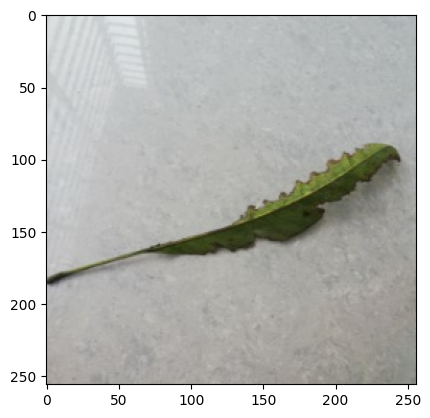

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

for images_batch, labels_batch in test_ds.take(1):

    first_image = (images_batch[0].numpy() * 255).astype('uint8')
    first_label = labels_batch[0].numpy()

    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])

    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

### Write a function for inference

In [ ]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

**Now run inference on few sample images**

In [ ]:
plt.figure(figsize=(12, 14))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow((image_batch[i].numpy() * 255).astype("uint8"))

        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")

        plt.axis("off")

### Saving the Model
We append the model to the list of models as a new version

In [ ]:
import os

model_save_dir = "/content/drive/MyDrive/Mango_Leafe_Care_App/models"
os.makedirs(model_save_dir, exist_ok=True)

model_version=max([int(i.split('.')[0]) for i in os.listdir(model_save_dir) if i.endswith('.keras')] + [0])+1
model.save(f"{model_save_dir}/{model_version}.keras")

# Loading the saved KERAS model for prediction

In [ ]:
import tensorflow as tf

# Assuming the last saved model is the one you want to load
model_save_dir = "/content/drive/MyDrive/Mango_Leafe_Care_App/models"
latest_model_version = max([int(i.split('.')[0]) for i in os.listdir(model_save_dir) if i.endswith('.keras')])
loaded_model_path = f"{model_save_dir}/{latest_model_version}.keras"

loaded_model = tf.keras.models.load_model(loaded_model_path)
loaded_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,027,802 (38.25 MB)

 Trainable params: 3,342,600 (12.75 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,685,202 (25.50 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


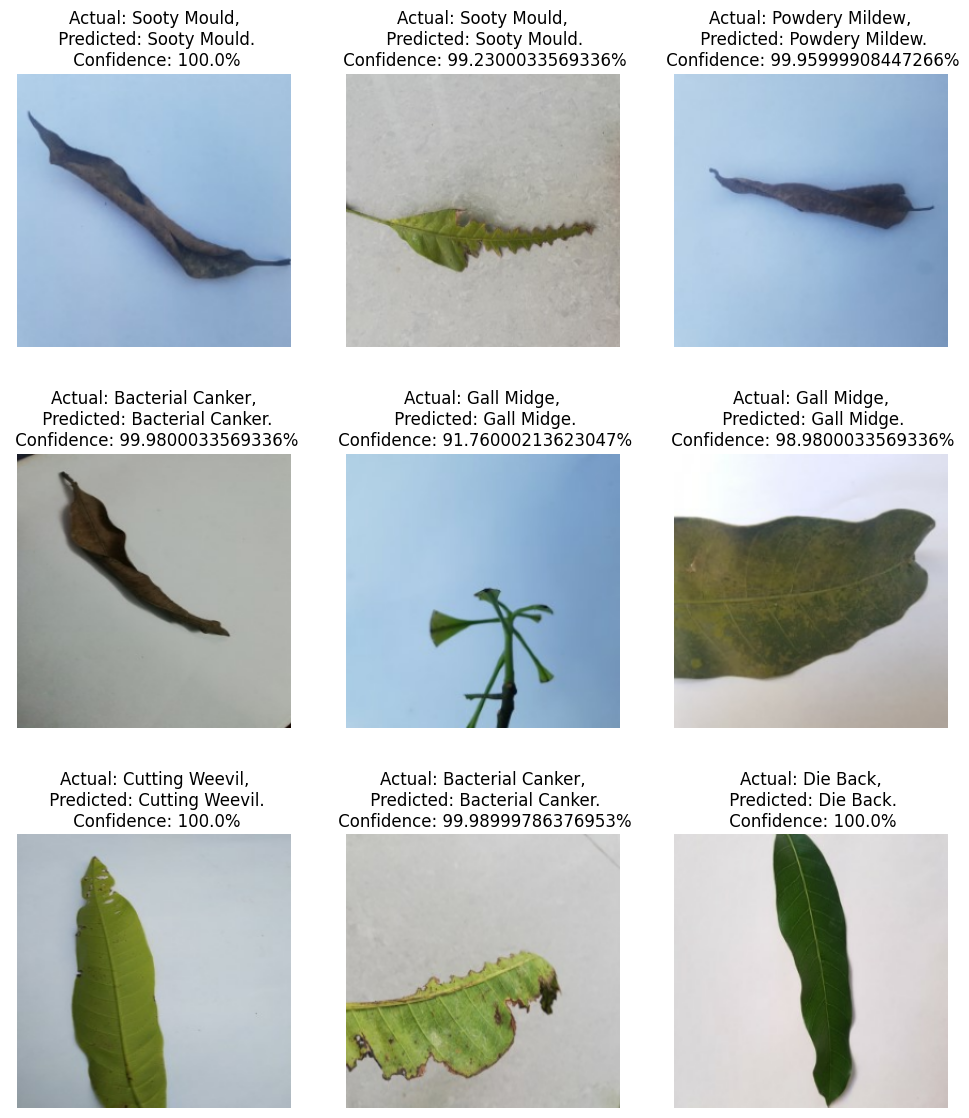

In [ ]:
# Inference on some images from test set
import numpy as np
import matplotlib.pyplot as plt

def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

plt.figure(figsize=(12, 14))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow((image_batch[i].numpy() * 255).astype("uint8"))

        predicted_class, confidence = predict(loaded_model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")

        plt.axis("off")

# Testing KERAS with online photos



In [ ]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from IPython.display import HTML

In [ ]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
IMAGE_WIDTH = 256 # Standardizing to a square size
IMAGE_HEIGHT = 256 # Standardizing to a square size

In [ ]:
from google.colab import files

print("Please upload the images for testing:")
uploaded_files = files.upload()

Please upload the images for testing:


Saving Mango Leaf Diseased.jpg to Mango Leaf Diseased.jpg


In [ ]:
! pip install tf_keras

In [ ]:
import os
model_save_dir = "/content/drive/MyDrive/Mango_Leafe_Care_App/models"
latest_model_version = max([int(i.split('.')[0]) for i in os.listdir(model_save_dir) if i.endswith('.keras')])
loaded_model_path = f"{model_save_dir}/{latest_model_version}.keras"

loaded_model = tf.keras.models.load_model(loaded_model_path)
loaded_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 28, 28, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 14, 14, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (32, 14, 14, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 25088)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 128)              │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 8)                │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,027,802 (38.25 MB)

 Trainable params: 3,342,600 (12.75 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,685,202 (25.50 MB)

Processing Mango Leaf Diseased.jpg...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


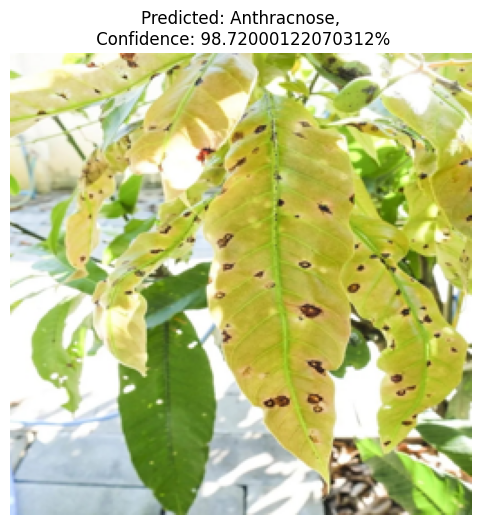

In [ ]:
import io
from PIL import Image
import numpy as np # Import numpy

# Redefine class_names directly as it's a static list obtained previously.
class_names = ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']

for filename, content in uploaded_files.items():
    print(f"Processing {filename}...")

    # Load image from bytes
    image_bytes = io.BytesIO(content)
    img = Image.open(image_bytes)

    # Convert PIL Image to TensorFlow format for prediction
    # Resize and convert to array
    img_resized = img.resize((IMAGE_WIDTH, IMAGE_HEIGHT))
    img_array = tf.keras.preprocessing.image.img_to_array(img_resized)

    # Expand dimensions to create a batch of 1 and normalize
    img_array = tf.expand_dims(img_array, 0)

    # Make prediction using the loaded model
    predictions = loaded_model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)

    # Display image and prediction
    plt.figure(figsize=(6, 6))
    plt.imshow(img_resized)
    plt.title(f"Predicted: {predicted_class},\n Confidence: {confidence}%")
    plt.axis("off")
    plt.show()

**The model succeeded to identify correctly with the given photos from other sources. Actual: Anthracnose, Predicted: Anthracnose**

# TFLite Conversion

## Imports

In [ ]:
!pip install --upgrade tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 14.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-pubsub 2.36.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>

In [ ]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from IPython.display import HTML

In [ ]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## TFLite with Post-Training Dynamic Range Quantization (PTDRQ)

In [ ]:
import tensorflow as tf
import os

# 1. Define paths
model_save_dir = "/content/drive/MyDrive/Mango_Leafe_Care_App/models"
saved_models = [int(i.split('.')[0]) for i in os.listdir(model_save_dir) if i.endswith('.keras')]
latest_model_version = max(saved_models) if saved_models else 1
loaded_model_path = f"{model_save_dir}/{latest_model_version}.keras"
tflite_save_path = f"{model_save_dir}/mangocare_model2_PTDRQ.tflite"

# 2. Load the trained Keras model
print(f"Loading model from: {loaded_model_path}")
model = tf.keras.models.load_model(loaded_model_path)

# 3. CRITICAL FIX: Lock the execution graph using a Concrete Function
print("Locking tensor shape via Concrete Function...")
@tf.function(input_signature=[tf.TensorSpec(shape=[1, 256, 256, 3], dtype=tf.float32)])
def serving_fn(inputs):
    return model(inputs)

concrete_func = serving_fn.get_concrete_function()

# 4. Initialize the TFLite Converter via Concrete Function
converter = tf.lite.TFLiteConverter.from_concrete_functions(
    [concrete_func],
    trackable_obj=model
)

# 5. Apply Quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# OPTIONAL: Uncomment the line below to use Float16 Quantization (Recommended for GPU)
# converter.target_spec.supported_types = [tf.float16]

print("Converting to TFLite...")
tflite_model = converter.convert()

# 6. Save the TFLite model
with open(tflite_save_path, "wb") as f:
    f.write(tflite_model)

print(f"Success! TFLite model saved to: {tflite_save_path}")

Loading model from: /content/drive/MyDrive/Mango_Leafe_Care_App/models/2.keras
Locking tensor shape via Concrete Function...
Converting to TFLite...
Success! TFLite model saved to: /content/drive/MyDrive/Mango_Leafe_Care_App/models/mangocare_model2_PTDRQ.tflite


### Evualtion of the quantized model (PTDRQ)

In [ ]:
import numpy as np
import tensorflow as tf
import os
import time

# Redefine constants and paths to ensure they are available
BATCH_SIZE = 64
IMAGE_WIDTH = 256
IMAGE_HEIGHT = 256

unzipped_dataset_base_path = "/content/MangoLeafBD_Dataset_Unzipped_train~val~test=70~20~10/MangoLeafBD_Disease_Dataset_Splitted_train~val~test=70~20~10"
model_save_dir = "/content/drive/MyDrive/Mango_Leafe_Care_App/models"

# Safely get the latest model version
saved_models = [int(i.split('.')[0]) for i in os.listdir(model_save_dir) if i.endswith('.keras')]
latest_model_version = max(saved_models) if saved_models else 1

loaded_keras_model_path = f"{model_save_dir}/{latest_model_version}.keras"
tflite_model_path = f"{model_save_dir}/mangocare_model2_PTDRQ.tflite"

# Re-create test_ds to ensure its availability and consistency
# If this cell is run independently, the dataset extraction might need to be run first.
print("Loading test dataset...")
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(unzipped_dataset_base_path, "test"),
    seed=123,
    shuffle=True,
    image_size=(IMAGE_HEIGHT,IMAGE_WIDTH),
    batch_size=BATCH_SIZE
)

print(f"Found {len(test_ds.class_names)} classes in the test dataset.")

# --- Evaluation of TFLite model ---
print(f"\nLoading TFLite model from: {tflite_model_path}")
interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_dtype = input_details[0]['dtype']
# The TFLite model was converted with a fixed batch size of 1
# So we will process images one by one.

tflite_predictions = []
true_labels = []

print("Evaluating TFLite model on the test set (image by image)...")
for images_batch, labels_batch in test_ds:
    for i in range(images_batch.shape[0]): # Iterate through each image in the batch
        single_image = images_batch[i:i+1].numpy() # Get one image as a batch of 1

        # Convert input data type if necessary for TFLite
        # The input to the model expects float32 (normalized 0-1) based on the `Rescaling` layer
        if input_dtype == np.float32 and single_image.dtype != np.float32:
            single_image = single_image.astype(np.float32)
        elif input_dtype == np.uint8 and single_image.dtype != np.uint8:
            # If the input expects uint8, it means the model was quantized to int8 input.
            # In that case, the input data needs to be scaled to 0-255.
            single_image = (single_image * 255).astype(np.uint8)

        interpreter.set_tensor(input_details[0]['index'], single_image)
        interpreter.invoke()
        output_data = interpreter.get_tensor(output_details[0]['index'])

        tflite_predictions.append(np.argmax(output_data[0])) # output_data is [1, num_classes]
    true_labels.extend(labels_batch.numpy()) # Collect all true labels from the batch

tflite_accuracy = np.sum(np.array(tflite_predictions) == np.array(true_labels)) / len(true_labels)
print(f"TFLite Model Accuracy on Test Set: {tflite_accuracy:.4f}")

# --- Comparison with Keras model ---
print(f"\nLoading Keras model from: {loaded_keras_model_path}")
keras_model = tf.keras.models.load_model(loaded_keras_model_path)

print("Evaluating Keras model on test_ds...")
keras_scores = keras_model.evaluate(test_ds, verbose=0)
keras_loss = keras_scores[0]
keras_accuracy = keras_scores[1]
print(f"Keras Model Evaluation Scores: Loss={keras_loss:.4f}, Accuracy={keras_accuracy:.4f}")

print("\n--- Model Comparison Summary ---")

# 1. Accuracy Comparison
print(f"Keras Model Test Accuracy: {keras_accuracy:.4f}")
print(f"TFLite Model Test Accuracy: {tflite_accuracy:.4f}")

# 2. Model Size Comparison
kf_size = os.path.getsize(loaded_keras_model_path) / (1024 * 1024) # Keras file size in MB
tfl_size = os.path.getsize(tflite_model_path) / (1024 * 1024) # TFLite file size in MB

print(f"\nKeras Model Size: {kf_size:.2f} MB")
print(f"TFLite Model Size: {tfl_size:.2f} MB")
print(f"Size Reduction: {((kf_size - tfl_size) / kf_size) * 100:.2f}%")

# 3. Basic Inference Time Comparison (single image)
# Prepare a single image for inference time testing
sample_image_batch, _ = next(iter(test_ds.take(1)))
single_sample_image_keras = sample_image_batch[0:1] # Batch of 1 for Keras
single_sample_image_tflite_raw = sample_image_batch[0].numpy() # Single image for TFLite

# Keras Model Inference Time
start_time = time.time()
_ = keras_model.predict(single_sample_image_keras, verbose=0)
keras_inference_time = time.time() - start_time

# TFLite Model Inference Time (ensure interpreter is reset for single inference)
interpreter_single_inference = tf.lite.Interpreter(model_path=tflite_model_path)
interpreter_single_inference.allocate_tensors()
input_details_single = interpreter_single_inference.get_input_details()
output_details_single = interpreter_single_inference.get_output_details()

# Ensure TFLite input tensor can handle a batch size of 1 for inference
# This check is crucial if the TFLite model was converted with a fixed batch size (e.g., 1 or BATCH_SIZE)
if input_details_single[0]['shape'][0] != 1:
    new_input_shape_single_inf = list(input_details_single[0]['shape'])
    new_input_shape_single_inf[0] = 1
    interpreter_single_inference.resize_tensor_input(input_details_single[0]['index'], new_input_shape_single_inf)
    interpreter_single_inference.allocate_tensors()

# Preprocess for TFLite if needed (rescaling is handled by model, but dtype might change)
input_data_for_tflite = np.expand_dims(single_sample_image_tflite_raw, axis=0) # Add batch dimension
if input_details_single[0]['dtype'] == np.uint8:
    # Assuming the input was originally 0-255 float and then rescaled for uint8
    input_data_for_tflite = (input_data_for_tflite * 255).astype(np.uint8)
elif input_details_single[0]['dtype'] == np.float32 and input_data_for_tflite.dtype != np.float32:
     input_data_for_tflite = input_data_for_tflite.astype(np.float32)

interpreter_single_inference.set_tensor(input_details_single[0]['index'], input_data_for_tflite)

start_time = time.time()
interpreter_single_inference.invoke()
_ = interpreter_single_inference.get_tensor(output_details_single[0]['index'])
tflite_inference_time = time.time() - start_time

print(f"\nKeras Model Single Image Inference Time: {keras_inference_time:.4f} seconds")
print(f"TFLite Model Single Image Inference Time: {tflite_inference_time:.4f} seconds")

# print("\n--- Further Considerations for Thesis ---")
# print("- You might want to consider evaluating more images for inference time and calculating an average.")
# print("- For a deeper academic analysis, consider comparing precision, recall, and F1-score for each class.")
# print("- Discuss trade-offs between model size, accuracy, and inference speed, which are critical for edge deployment.")


Loading test dataset...
Found 400 files belonging to 8 classes.
Found 8 classes in the test dataset.

Loading TFLite model from: /content/drive/MyDrive/Mango_Leafe_Care_App/models/mangocare_model2_PTDRQ.tflite
Evaluating TFLite model on the test set (image by image)...


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


TFLite Model Accuracy on Test Set: 0.1250

Loading Keras model from: /content/drive/MyDrive/Mango_Leafe_Care_App/models/2.keras
Evaluating Keras model on test_ds...
Keras Model Evaluation Scores: Loss=0.1676, Accuracy=0.9675

--- Model Comparison Summary ---
Keras Model Test Accuracy: 0.9675
TFLite Model Test Accuracy: 0.1250

Keras Model Size: 38.32 MB
TFLite Model Size: 0.01 MB
Size Reduction: 99.97%

Keras Model Single Image Inference Time: 0.1160 seconds
TFLite Model Single Image Inference Time: 0.0357 seconds

--- Further Considerations for Thesis ---
- You might want to consider evaluating more images for inference time and calculating an average.
- For a deeper academic analysis, consider comparing precision, recall, and F1-score for each class.
- Discuss trade-offs between model size, accuracy, and inference speed, which are critical for edge deployment.


### Evaluate a single image using the TFLite quantized model

Loading TFLite model from: /content/drive/MyDrive/Mango_Leafe_Care_App/models/mangocare_model_PTDRQ.tflite


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


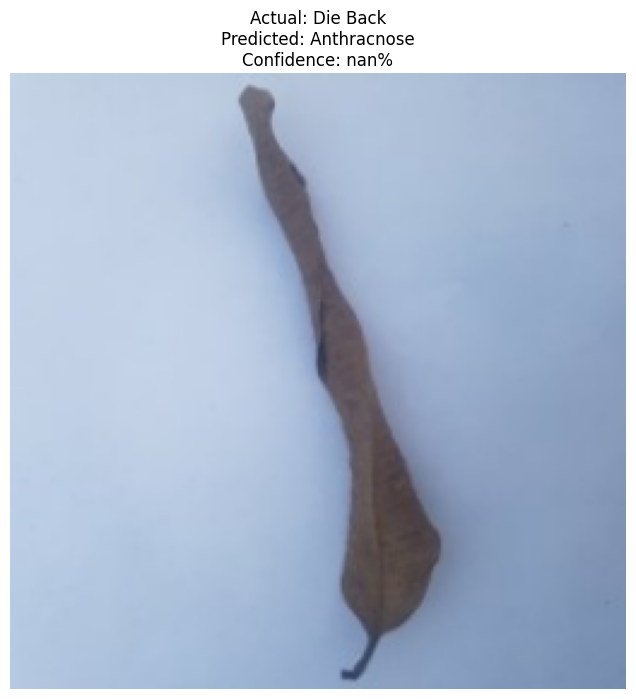

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os

# 1. Redefine paths
model_save_dir = "/content/drive/MyDrive/Mango_Leafe_Care_App/models"
tflite_model_path = f"{model_save_dir}/mangocare_model_PTDRQ.tflite"

# 2. Load the TFLite model
print(f"Loading TFLite model from: {tflite_model_path}")
interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
input_dtype = input_details[0]['dtype']

# 3. Get a single image from the test dataset
for images, labels in test_ds.take(1):
    single_image_original = images[0].numpy()  # Get the first image (Values: 0 to 255)
    single_label = labels[0].numpy()           # Get true label
    break

# 4. PREPROCESSING (CRITICAL FIX)
# Expand dimensions to match [1, 256, 256, 3]
img_for_tflite = np.expand_dims(single_image_original, axis=0)

if input_dtype == np.float32:
    # NORMALIZE the image! Divide by 255.0 to scale pixels between 0.0 and 1.0.
    # This prevents the NaN Activation Explosion.
    img_for_tflite = img_for_tflite.astype(np.float32) / 255.0
else:
    raise ValueError("Expected a float32 input model. Check conversion script.")

# 5. Run Inference
interpreter.set_tensor(input_details[0]['index'], img_for_tflite)
interpreter.invoke()
predictions = interpreter.get_tensor(output_details[0]['index'])

# 6. Extract Results
predicted_class_idx = np.argmax(predictions[0])
predicted_class = class_names[predicted_class_idx]
confidence = round(100 * (np.max(predictions[0])), 2)
actual_class = class_names[single_label]

# 7. Display the Result
plt.figure(figsize=(8, 8))
# Ensure the display image remains uint8 so matplotlib renders it properly
plt.imshow(single_image_original.astype("uint8"))
plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence}%")
plt.axis("off")
plt.show()

## TFLite with Float16

In [ ]:
import tensorflow as tf
import os

# 1. Define paths
model_save_dir = "/content/drive/MyDrive/Mango_Leafe_Care_App/models"
# Safely grab the latest Keras model you just trained
saved_models = [int(i.split('.')[0]) for i in os.listdir(model_save_dir) if i.endswith('.keras')]
latest_model_version = max(saved_models) if saved_models else 1
loaded_model_path = f"{model_save_dir}/{latest_model_version}.keras"
tflite_save_path = f"{model_save_dir}/mangocare_model_float16.tflite"

# 2. Load the retrained Keras model
print(f"Loading Keras model from: {loaded_model_path}")
model = tf.keras.models.load_model(loaded_model_path)

# 3. Initialize Standard Converter
print("Initializing TFLite Converter...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# 4. Apply Float16 Quantization (The GPU Standard)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

# 5. Convert and Save
print("Converting to Float16 TFLite... Please wait.")
tflite_model = converter.convert()

with open(tflite_save_path, "wb") as f:
    f.write(tflite_model)

print(f"Success! Optimized TFLite model saved to: {tflite_save_path}")

# Print file size comparison
keras_size = os.path.getsize(loaded_model_path) / (1024 * 1024)
tflite_size = os.path.getsize(tflite_save_path) / (1024 * 1024)
print(f"Original Keras Size: {keras_size:.2f} MB")
print(f"New TFLite Size:     {tflite_size:.2f} MB")

Loading Keras model from: /content/drive/MyDrive/Mango_Leafe_Care_App/models/7.keras
Initializing TFLite Converter...
Converting to Float16 TFLite... Please wait.
Saved artifact at '/tmp/tmpzcd0u2jt'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  136005642925264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136005642914512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136005642924496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136005642916240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136005642924304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136005642924688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136005642926032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136005642912016: TensorSpec(shape=(), dtype=tf.resource, name=

### Evaluation of Float16 Model

In [ ]:
import tensorflow as tf
import numpy as np
import time

# 1. Define paths
model_save_dir = "/content/drive/MyDrive/Mango_Leafe_Care_App/models"
tflite_model_path = f"{model_save_dir}/mangocare_model_float16.tflite"

# 2. Initialize Interpreter
print(f"Loading Float16 TFLite model from: {tflite_model_path}")
interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# 3. Setup Metrics
correct_predictions = 0
inference_times_ms = []

# Unbatch the test dataset to evaluate 1 image at a time
unbatched_test_ds = test_ds.unbatch()
total_images_count = len(list(unbatched_test_ds.as_numpy_iterator()))
print(f"\nEvaluating {total_images_count} test images. Please wait...")

# 4. Evaluation Loop
current_image = 0
for image, label in unbatched_test_ds:
    current_image += 1

    # CRITICAL PREPROCESSING:
    input_data = np.expand_dims(image.numpy(), axis=0).astype(np.float32)

    # Start Stopwatch
    start_time = time.perf_counter()

    # Run Inference
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])

    # Stop Stopwatch
    end_time = time.perf_counter()

    # Calculate Latency
    inference_times_ms.append((end_time - start_time) * 1000)

    # Get Prediction
    predicted_class = np.argmax(output_data[0])

    if predicted_class == label.numpy():
        correct_predictions += 1

    if current_image % 100 == 0:
        print(f"Processed {current_image}/{total_images_count} images...")

# 5. Calculate Final Metrics
accuracy = (correct_predictions / total_images_count) * 100
avg_latency = np.mean(inference_times_ms)

print("\n" + "="*40)
print("FINAL FLOAT16 TFLITE EVALUATION RESULTS")
print("="*40)
print(f"Overall Accuracy:  {accuracy:.2f}%")
print(f"Average Latency:   {avg_latency:.2f} ms")
print("="*40)

Loading Float16 TFLite model from: /content/drive/MyDrive/Mango_Leafe_Care_App/models/mangocare_model_float16.tflite

Evaluating 400 test images. Please wait...
Processed 100/400 images...
Processed 200/400 images...
Processed 300/400 images...
Processed 400/400 images...

FINAL FLOAT16 TFLITE EVALUATION RESULTS
Overall Accuracy:  97.25%
Average Latency:   29.85 ms


### Evaluation of Keras Model Latency

In [14]:
import tensorflow as tf
import numpy as np
import time
import os

# 1. Define paths (re-using existing definitions)
model_save_dir = "/content/drive/MyDrive/Mango_Leafe_Care_App/models"

saved_models = [int(i.split('.')[0]) for i in os.listdir(model_save_dir) if i.endswith('.keras')]
latest_model_version = max(saved_models) if saved_models else 1
keras_model_path = f"{model_save_dir}/{latest_model_version}.keras"

# 2. Load the Keras model
print(f"\nLoading Keras model from: {keras_model_path}")
keras_model = tf.keras.models.load_model(keras_model_path)

# 3. Setup Metrics
keras_inference_times_ms = []

# Unbatch the test dataset to evaluate 1 image at a time
unbatched_test_ds_keras = test_ds.unbatch()

print("Evaluating Keras model on the test set (image by image) for latency...")

# 4. Evaluation Loop
current_image_keras = 0
for image, label in unbatched_test_ds_keras:
    current_image_keras += 1

    # CRITICAL PREPROCESSING:
    # The test_ds is already normalized (0-1 float32) by the time it gets here
    # Keras model expects a batch dimension, so expand dims
    input_data_keras = np.expand_dims(image.numpy(), axis=0).astype(np.float32)

    # Start Stopwatch
    start_time_keras = time.perf_counter()

    # Run Inference
    _ = keras_model.predict(input_data_keras, verbose=0)

    # Stop Stopwatch
    end_time_keras = time.perf_counter()

    # Calculate Latency
    keras_inference_times_ms.append((end_time_keras - start_time_keras) * 1000)

    if current_image_keras % 100 == 0:
        print(f"Processed {current_image_keras}/{len(list(unbatched_test_ds_keras.as_numpy_iterator()))} images...")

# 5. Calculate Final Metrics
avg_latency_keras = np.mean(keras_inference_times_ms)

print("\n" + "="*40)
print("FINAL KERAS MODEL LATENCY RESULTS")
print("="*40)
print(f"Average Keras Model Latency: {avg_latency_keras:.2f} ms")
print("="*40)



Loading Keras model from: /content/drive/MyDrive/Mango_Leafe_Care_App/models/7.keras
Evaluating Keras model on the test set (image by image) for latency...
Processed 100/400 images...
Processed 200/400 images...
Processed 300/400 images...
Processed 400/400 images...

FINAL KERAS MODEL LATENCY RESULTS
Average Keras Model Latency: 135.07 ms


# Exploratory Data Analysis

In [ ]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

# Define the path to your training data
train_dir = "/content/MangoLeafBD_Dataset_Unzipped_train~val~test=70~20~10/MangoLeafBD_Disease_Dataset_Splitted_train~val~test=70~20~10/train"

# Get the list of classes directly from the folder names
class_names = sorted(os.listdir(train_dir))

In [ ]:
class_names

['Anthracnose',
 'Bacterial Canker',
 'Cutting Weevil',
 'Die Back',
 'Gall Midge',
 'Healthy',
 'Powdery Mildew',
 'Sooty Mould']

### 1. Class Distribution Bar Chart

/tmp/ipykernel_3201/2668469405.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=class_counts, palette="viridis")


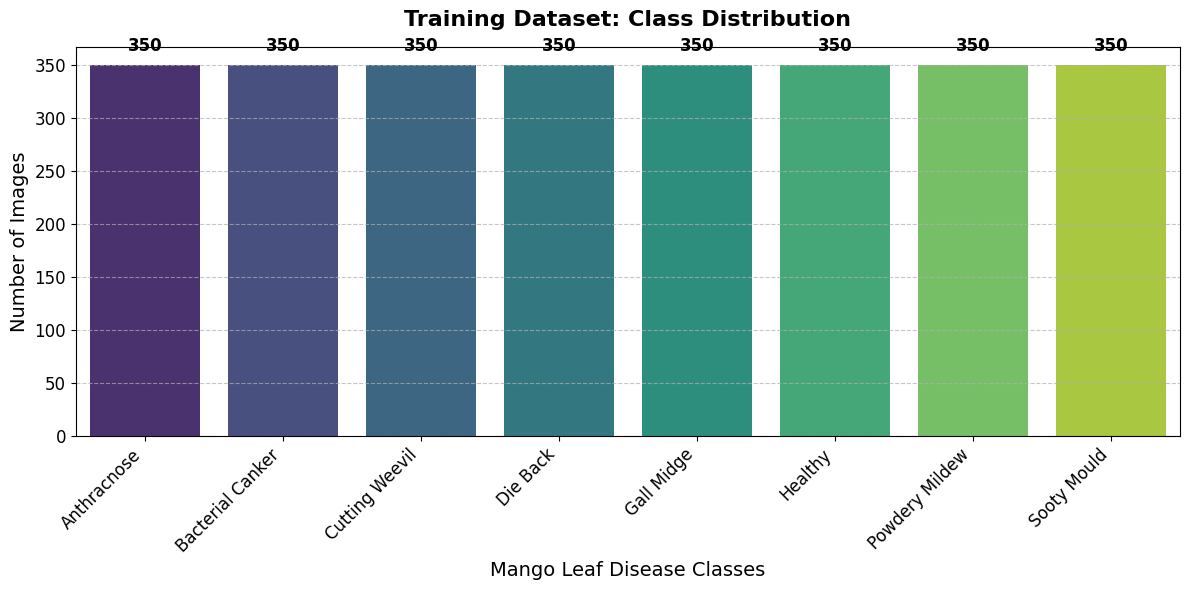

In [ ]:
# Count the number of images per class
class_counts = []
for disease in class_names:
    disease_path = os.path.join(train_dir, disease)
    num_images = len(glob.glob(os.path.join(disease_path, "*.jpg"))) # Adjust extension if needed (.jpeg, .png)
    class_counts.append(num_images)

# Generate the Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(x=class_names, y=class_counts, palette="viridis")

# Add text labels on top of each bar
for i, count in enumerate(class_counts):
    plt.text(i, count + 10, str(count), ha='center', va='bottom', fontsize=12, weight='bold')

plt.title("Training Dataset: Class Distribution", fontsize=16, weight='bold', pad=15)
plt.xlabel("Mango Leaf Disease Classes", fontsize=14)
plt.ylabel("Number of Images", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
# plt.savefig('class_distribution.png', dpi=300) # Uncomment to save for thesis
plt.show()

### 2. Raw Data Sample Grid

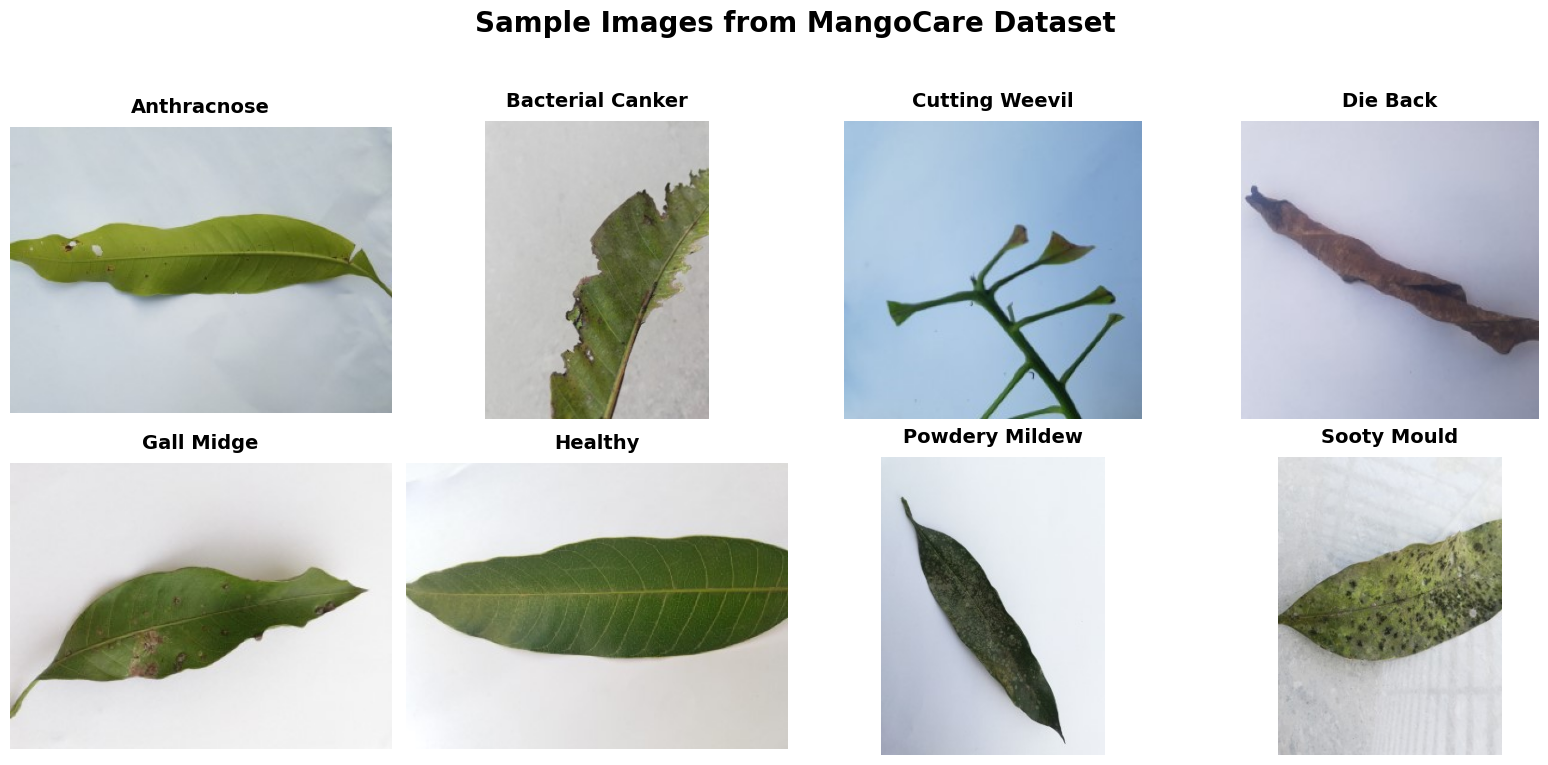

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Sample Images from MangoCare Dataset", fontsize=20, weight='bold')

axes = axes.flatten()

for i, disease in enumerate(class_names):
    disease_path = os.path.join(train_dir, disease)
    # Get all images in the class folder
    all_images = glob.glob(os.path.join(disease_path, "*.*"))

    # Pick a random image
    random_image_path = random.choice(all_images)
    img = Image.open(random_image_path)

    # Plot
    axes[i].imshow(img)
    axes[i].set_title(disease, fontsize=14, weight='bold', pad=10)
    axes[i].axis('off') # Hide axes for a cleaner look

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.savefig('raw_data_grid.png', dpi=300)
plt.show()

### 3. Image Resolution / Aspect Ratio Scatter Plot

Scanning image resolutions... Please wait.


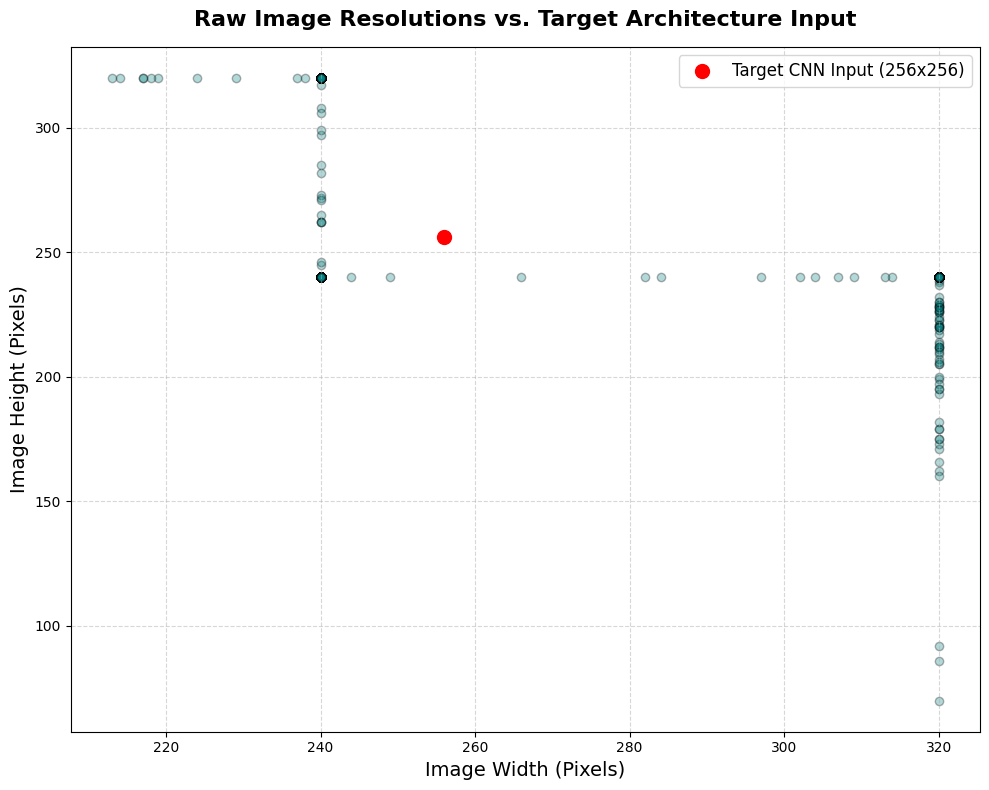

In [ ]:
widths = []
heights = []

print("Scanning image resolutions... Please wait.")
for disease in class_names:
    disease_path = os.path.join(train_dir, disease)
    for img_path in glob.glob(os.path.join(disease_path, "*.*")):
        try:
            # PIL lazy-loads the file just to read the header (super fast)
            with Image.open(img_path) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
        except Exception as e:
            continue

# Generate Scatter Plot
plt.figure(figsize=(10, 8))
plt.scatter(widths, heights, alpha=0.3, color='teal', edgecolors='k')

# Draw a red dot representing your target size (256x256)
plt.scatter([256], [256], color='red', s=100, label='Target CNN Input (256x256)', zorder=5)

plt.title("Raw Image Resolutions vs. Target Architecture Input", fontsize=16, weight='bold', pad=15)
plt.xlabel("Image Width (Pixels)", fontsize=14)
plt.ylabel("Image Height (Pixels)", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
# plt.savefig('resolution_scatter.png', dpi=300)
plt.show()

### 4. RGB Channel Histograms

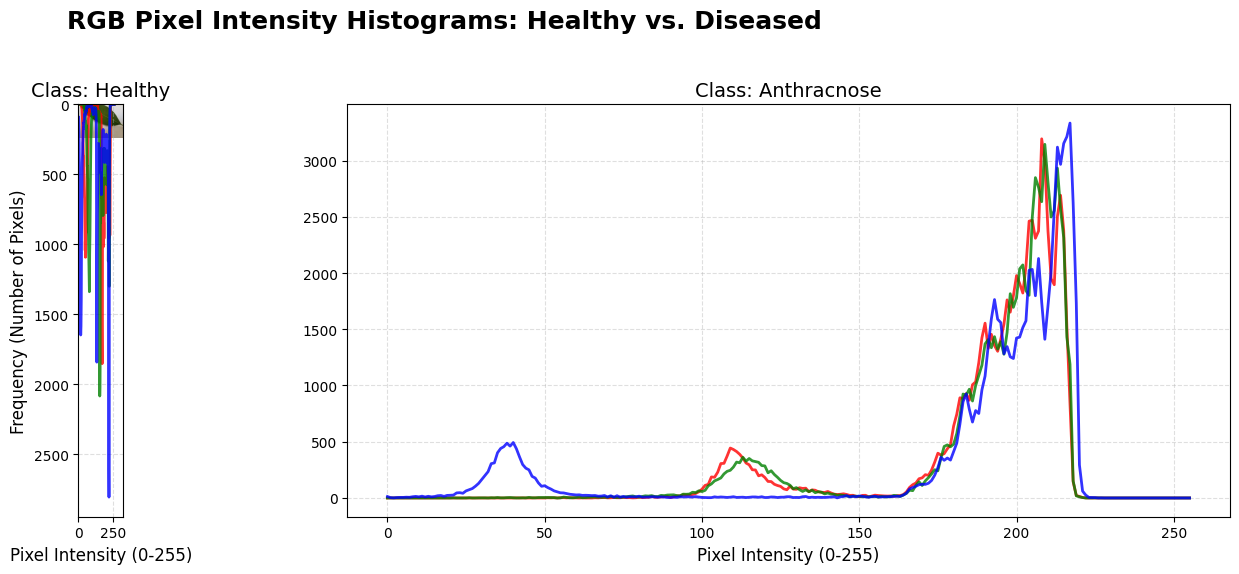

In [ ]:
# Define the two classes you want to compare
class_1 = "Healthy"
class_2 = "Anthracnose"

def get_random_image_array(disease_name):
    path = os.path.join(train_dir, disease_name)
    img_path = random.choice(glob.glob(os.path.join(path, "*.*")))
    # Read with OpenCV and convert from BGR to RGB
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

img_healthy = get_random_image_array(class_1)
img_diseased = get_random_image_array(class_2)

colors = ('r', 'g', 'b')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("RGB Pixel Intensity Histograms: Healthy vs. Diseased", fontsize=18, weight='bold')

# Plot Healthy Histogram
axes[0].imshow(img_healthy) # Show thumbnail inset? We'll just do the line plot
for i, color in enumerate(colors):
    hist = cv2.calcHist([img_healthy], [i], None, [256], [0, 256])
    axes[0].plot(hist, color=color, linewidth=2, alpha=0.8)
axes[0].set_title(f"Class: {class_1}", fontsize=14)
axes[0].set_xlabel("Pixel Intensity (0-255)", fontsize=12)
axes[0].set_ylabel("Frequency (Number of Pixels)", fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.4)

# Plot Diseased Histogram
for i, color in enumerate(colors):
    hist = cv2.calcHist([img_diseased], [i], None, [256], [0, 256])
    axes[1].plot(hist, color=color, linewidth=2, alpha=0.8)
axes[1].set_title(f"Class: {class_2}", fontsize=14)
axes[1].set_xlabel("Pixel Intensity (0-255)", fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.savefig('rgb_histograms.png', dpi=300)
plt.show()

### Visualize some of the images from our train dataset

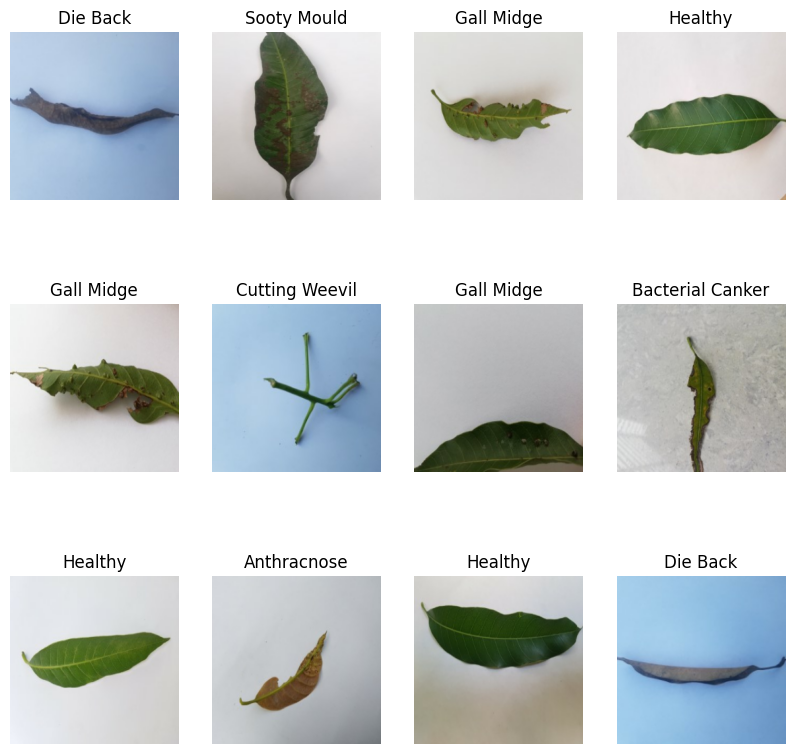

In [ ]:
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow((image_batch[i].numpy() * 255).astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

In [ ]:
len(train_ds)

44

In [ ]:
len(val_ds)

13

In [ ]:
len(test_ds)

7

# Evaluation Metrices

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Define Paths
model_save_dir = "/content/drive/MyDrive/Mango_Leafe_Care_App/models"

# Find the latest Keras model automatically
saved_models = [int(i.split('.')[0]) for i in os.listdir(model_save_dir) if i.endswith('.keras')]
latest_model_version = max(saved_models) if saved_models else 1

keras_model_path = f"{model_save_dir}/{latest_model_version}.keras"
tflite_model_path = f"{model_save_dir}/mangocare_model_float16.tflite"



Loading Keras Model: /content/drive/MyDrive/Mango_Leafe_Care_App/models/7.keras
Loading TFLite Model: /content/drive/MyDrive/Mango_Leafe_Care_App/models/mangocare_model_float16.tflite


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



Running Inference on Test Dataset... This may take a minute.
Inference Complete!

KERAS BASELINE MODEL - CLASSIFICATION REPORT
                  precision    recall  f1-score   support

     Anthracnose     1.0000    0.9600    0.9796        50
Bacterial Canker     0.9804    1.0000    0.9901        50
  Cutting Weevil     1.0000    1.0000    1.0000        50
        Die Back     0.9615    1.0000    0.9804        50
      Gall Midge     0.9574    0.9000    0.9278        50
         Healthy     0.9615    1.0000    0.9804        50
  Powdery Mildew     0.9800    0.9800    0.9800        50
     Sooty Mould     0.9400    0.9400    0.9400        50

        accuracy                         0.9725       400
       macro avg     0.9726    0.9725    0.9723       400
    weighted avg     0.9726    0.9725    0.9723       400


FLOAT16 TFLITE MODEL - CLASSIFICATION REPORT
                  precision    recall  f1-score   support

     Anthracnose     1.0000    0.9600    0.9796        50
Bacterial 

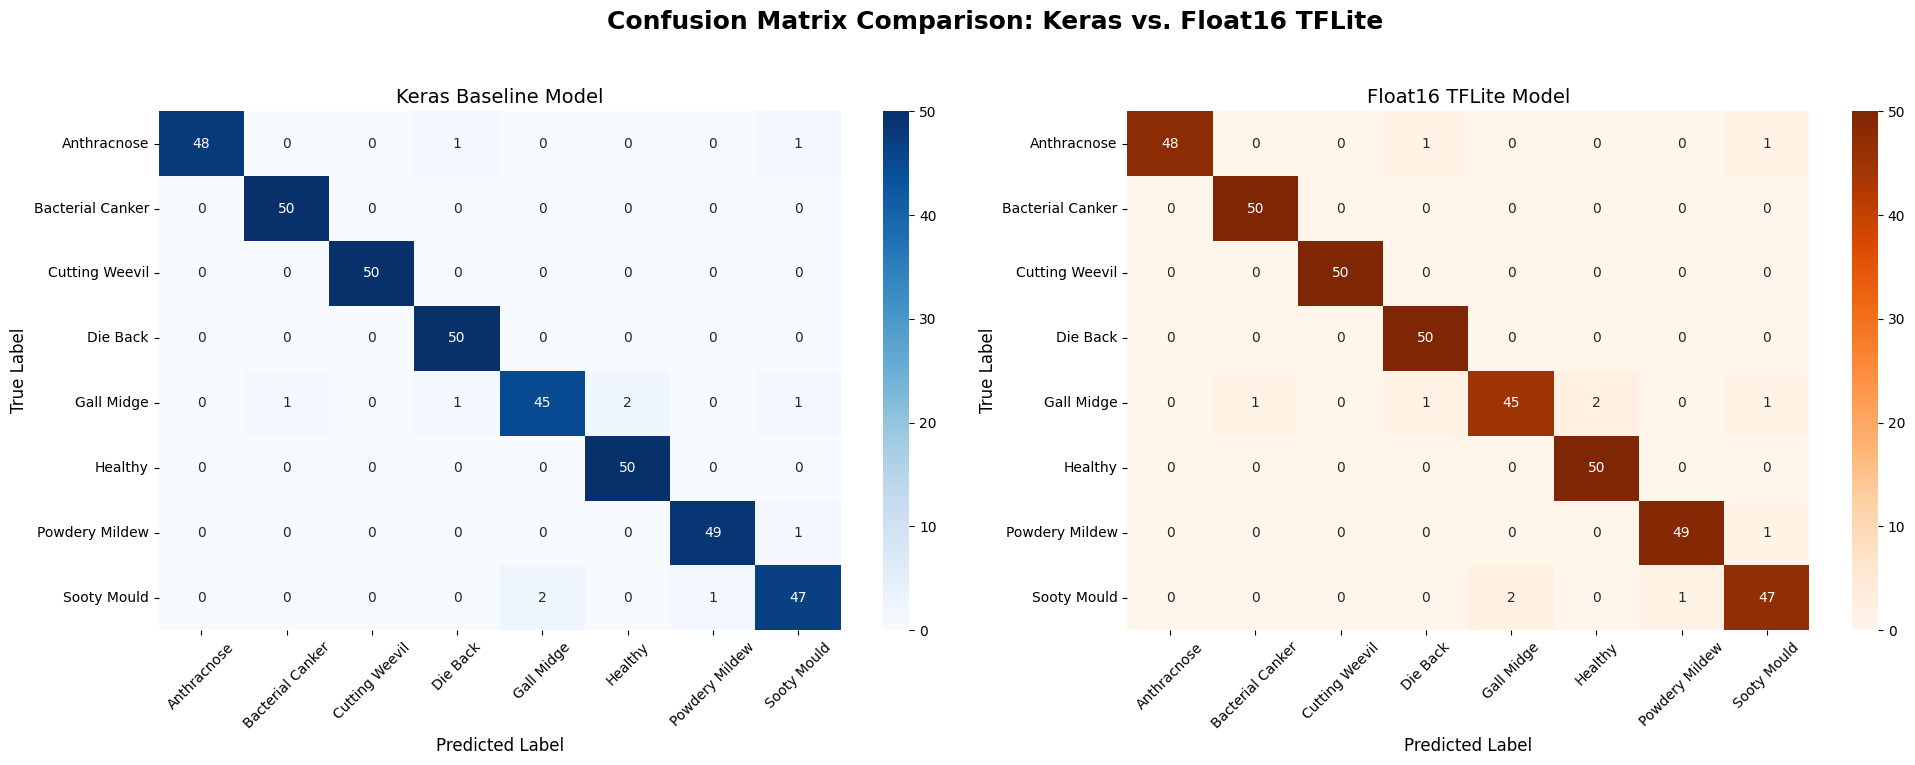

In [ ]:
# 2. Load Both Models
print(f"Loading Keras Model: {keras_model_path}")
keras_model = tf.keras.models.load_model(keras_model_path)

print(f"Loading TFLite Model: {tflite_model_path}")
interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# 3. Initialize Metric Trackers
y_true = []
y_pred_keras = []
y_pred_tflite = []

print("\nRunning Inference on Test Dataset... This may take a minute.")

# 4. Synchronized Evaluation Loop
# We iterate through the batched test_ds to ensure Keras and TFLite see the exact same data
for images, labels in test_ds:
    # A. Record True Labels for this batch
    y_true.extend(labels.numpy())

    # B. Keras Batch Inference
    # Keras can handle the whole batch of 64 at once
    k_preds = keras_model.predict(images, verbose=0)
    y_pred_keras.extend(np.argmax(k_preds, axis=1))

    # C. TFLite Single-Image Inference
    # TFLite needs batch size 1, so we loop through the 64 images in this batch individually
    for i in range(images.shape[0]):
        # Extract one image and keep the batch dimension: shape becomes (1, 256, 256, 3)
        # Note: We do NOT divide by 255.0 here because test_ds is already normalized!
        single_image = np.expand_dims(images[i].numpy(), axis=0)

        interpreter.set_tensor(input_details[0]['index'], single_image)
        interpreter.invoke()
        t_preds = interpreter.get_tensor(output_details[0]['index'])
        y_pred_tflite.append(np.argmax(t_preds[0]))

print("Inference Complete!\n")

# 5. Print Academic Classification Reports
print("="*60)
print("KERAS BASELINE MODEL - CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred_keras, target_names=class_names, digits=4))

print("\n" + "="*60)
print("FLOAT16 TFLITE MODEL - CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred_tflite, target_names=class_names, digits=4))

# 6. Generate Side-by-Side Confusion Matrices
cm_keras = confusion_matrix(y_true, y_pred_keras)
cm_tflite = confusion_matrix(y_true, y_pred_tflite)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Confusion Matrix Comparison: Keras vs. Float16 TFLite', fontsize=18, weight='bold')

# Keras Heatmap
sns.heatmap(cm_keras, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title('Keras Baseline Model', fontsize=14)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# TFLite Heatmap
sns.heatmap(cm_tflite, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_title('Float16 TFLite Model', fontsize=14)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

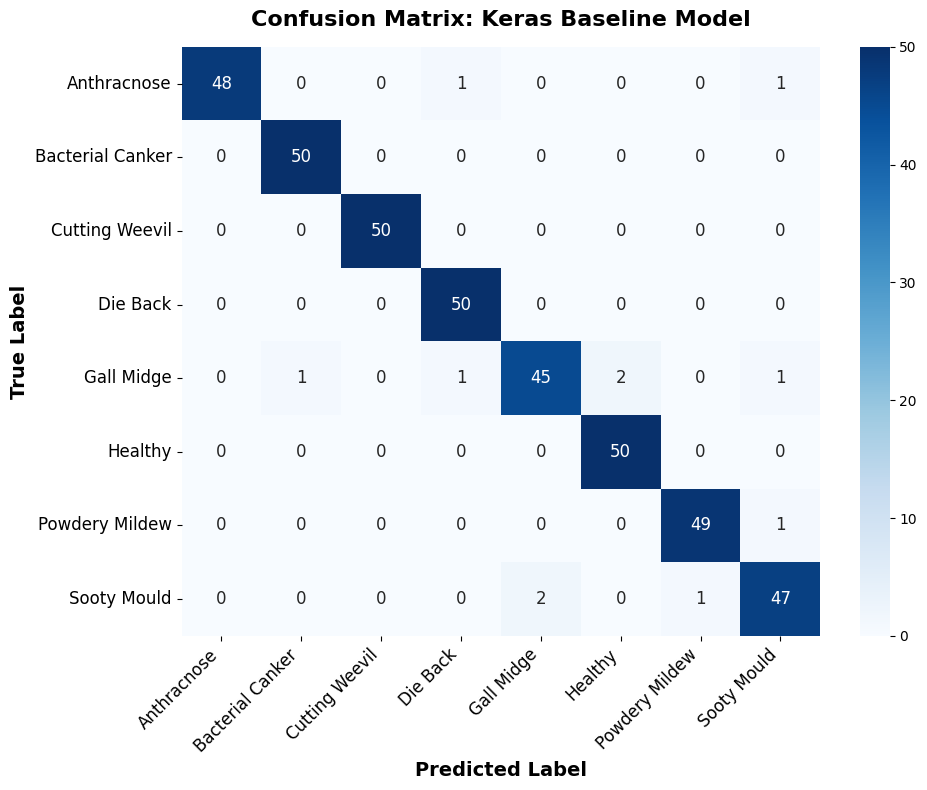

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate the raw mathematical matrices
cm_keras = confusion_matrix(y_true, y_pred_keras)
cm_tflite = confusion_matrix(y_true, y_pred_tflite)

# ==========================================
# 2. Plot Keras Model Matrix (Standalone)
# ==========================================
plt.figure(figsize=(10, 8))
sns.heatmap(cm_keras, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 12}) # Larger numbers inside the boxes

plt.title('Confusion Matrix: Keras Baseline Model', fontsize=16, weight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=14, weight='bold')
plt.ylabel('True Label', fontsize=14, weight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.savefig('keras_confusion_matrix.png', dpi=300) # Un-comment to save directly to Colab files
plt.show()



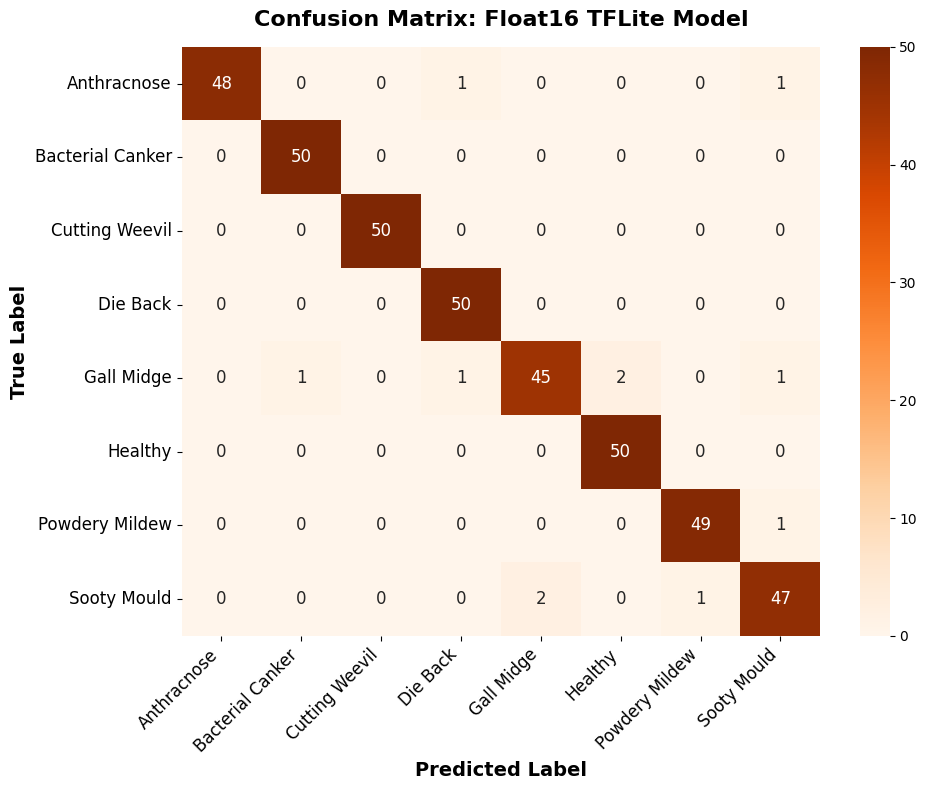

In [ ]:
# ==========================================
# 3. Plot TFLite Model Matrix (Standalone)
# ==========================================
plt.figure(figsize=(10, 8))
sns.heatmap(cm_tflite, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 12})

plt.title('Confusion Matrix: Float16 TFLite Model', fontsize=16, weight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=14, weight='bold')
plt.ylabel('True Label', fontsize=14, weight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.savefig('tflite_confusion_matrix.png', dpi=300, bbox_inches='tight') # Save with tight bounding box
plt.show()

# Grad-CAM (Standard)

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import os
import random
import glob

# 1. Configuration & Paths
model_save_dir = "/content/drive/MyDrive/Mango_Leafe_Care_App/models"
saved_models = [int(i.split('.')[0]) for i in os.listdir(model_save_dir) if i.endswith('.keras')]
latest_model_version = max(saved_models) if saved_models else 1
keras_model_path = f"{model_save_dir}/{latest_model_version}.keras"

train_dir = "/content/MangoLeafBD_Dataset_Unzipped_train~val~test=70~20~10/MangoLeafBD_Disease_Dataset_Splitted_train~val~test=70~20~10/train"
class_names = sorted(os.listdir(train_dir))

# 2. Load the Keras Model
print(f"Loading Model: {keras_model_path}")
model = tf.keras.models.load_model(keras_model_path)

# 3. Dynamically Find the Last Conv2D Layer
# We loop backwards through your architecture to find the final feature map
last_conv_layer_name = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print(f"Targeting final Conv2D layer: {last_conv_layer_name}")

# 4. The Grad-CAM Algorithm
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Create a model that outputs the last conv layer's activations and the final predictions
    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Record operations for automatic differentiation
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Calculate the gradient of the top predicted class with respect to the output feature map
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # Pool the gradients over the spatial dimensions
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each channel in the feature map by "how important this channel is"
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Apply ReLU (only care about features that have a positive influence on the class)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# 5. Helper Function to Display and Save
def display_gradcam(img_path, heatmap, target_class, predicted_class, confidence, alpha=0.6):
    # Load original image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))

    # Resize heatmap to match image size
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Convert heatmap to RGB format using a colormap (JET is standard for academic papers)
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Superimpose heatmap onto the original image
    superimposed_img = cv2.addWeighted(heatmap, alpha, img, 1 - alpha, 0)

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle(f"Grad-CAM Analysis\nTrue: {target_class} | Pred: {predicted_class} ({confidence:.1f}%)",
                 fontsize=16, weight='bold')

    axes[0].imshow(img)
    axes[0].set_title("Original Image", fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(superimposed_img)
    axes[1].set_title("Grad-CAM Heatmap", fontsize=14)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()



Loading Model: /content/drive/MyDrive/Mango_Leafe_Care_App/models/7.keras
Targeting final Conv2D layer: conv2d_3


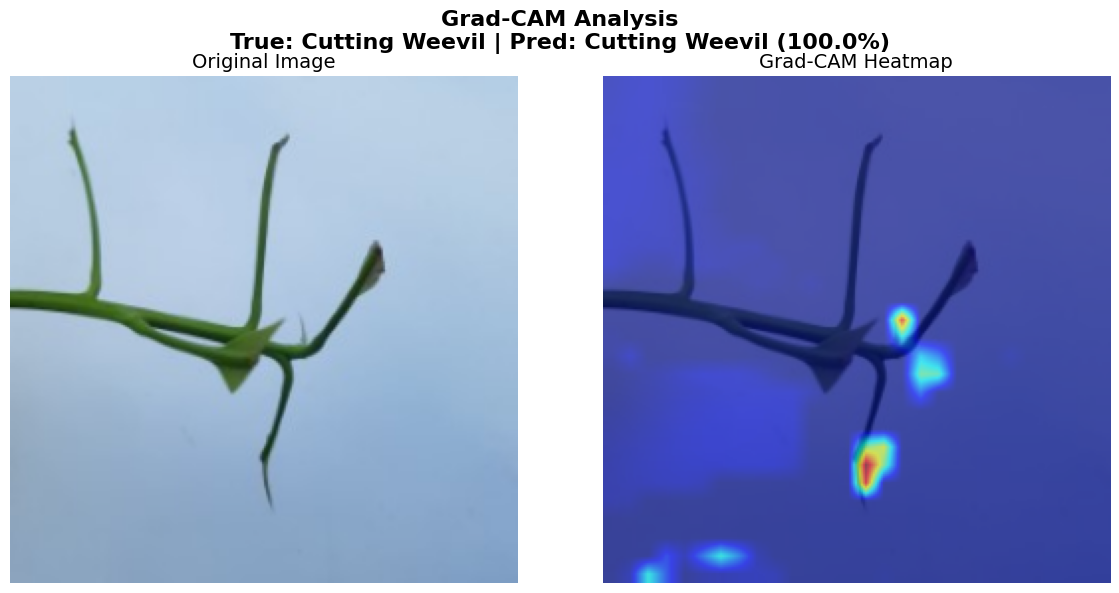

In [ ]:
# ==========================================
# 6. Run Analysis on a Random Diseased Leaf
# ==========================================
# Let's test it on a disease that has obvious visual spots (like Anthracnose or Canker)
target_disease = "Cutting Weevil"
disease_path = os.path.join(train_dir, target_disease)
random_img_path = random.choice(glob.glob(os.path.join(disease_path, "*.*")))

# Preprocess the image for the model (Must mimic your .map() function!)
img = tf.keras.preprocessing.image.load_img(random_img_path, target_size=(256, 256))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0  # <--- Critical normalization step!

# Get prediction
preds = model.predict(img_array, verbose=0)
pred_idx = np.argmax(preds[0])
confidence = np.max(preds[0]) * 100
predicted_label = class_names[pred_idx]

# Generate heatmap
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=pred_idx)

# Display
display_gradcam(random_img_path, heatmap, target_disease, predicted_label, confidence)